In [1]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import json
import seaborn as sns
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import numpy as np

# Read the JSON data
with open('boardgames_100.json', 'r') as f:
    boardgames = json.load(f)

# Create DataFrame for nodes (games)
nodes_data = []
for game in boardgames:
    nodes_data.append({
        'id': game['id'],
        'title': game['title'],
        'year': game['year'],
        'rank': game['rank'],
        'rating': game['rating']['rating'],
        'num_reviews': game['rating']['num_of_reviews']
    })

nodes_df = pd.DataFrame(nodes_data)
print("Nodes DataFrame (first 5 rows):")
print(nodes_df.head())

Nodes DataFrame (first 5 rows):
       id                              title  year  rank   rating  num_reviews
0  174430                         Gloomhaven  2017     1  8.67527        54330
1  224517                  Brass: Birmingham  2018     2  8.65313        33285
2  161936          Pandemic Legacy: Season 1  2015     3  8.56688        48768
3  342942                           Ark Nova  2021     4  8.56684        23194
4  233078  Twilight Imperium: Fourth Edition  2017     5  8.64490        19295


In [2]:
# Create list of edges based on fans_liked recommendations
edges = []
for game in boardgames:
    if 'recommendations' in game and 'fans_liked' in game['recommendations']:
        source_id = game['id']
        for target_id in game['recommendations']['fans_liked']:
            # Only include edges where both games are in our dataset
            if target_id in nodes_df['id'].values:
                edges.append((source_id, target_id))

edges_df = pd.DataFrame(edges, columns=['source', 'target'])
print("\nEdges DataFrame (first 5 rows):")
print(edges_df.head())


Edges DataFrame (first 5 rows):
   source  target
0  174430  291457
1  174430  205059
2  174430  192135
3  174430  316554
4  174430  266507


In [3]:
# Create a lookup dictionary for game titles
id_to_title = {game['id']: game['title'] for game in boardgames}
id_to_rank = {game['id']: game['rank'] for game in boardgames}
id_to_rating = {game['id']: game['rating']['rating'] for game in boardgames}

# Create a NetworkX graph
G = nx.DiGraph()  # Directed graph since recommendations are directional


Graph Statistics:
Number of nodes: 100
Number of edges: 1381


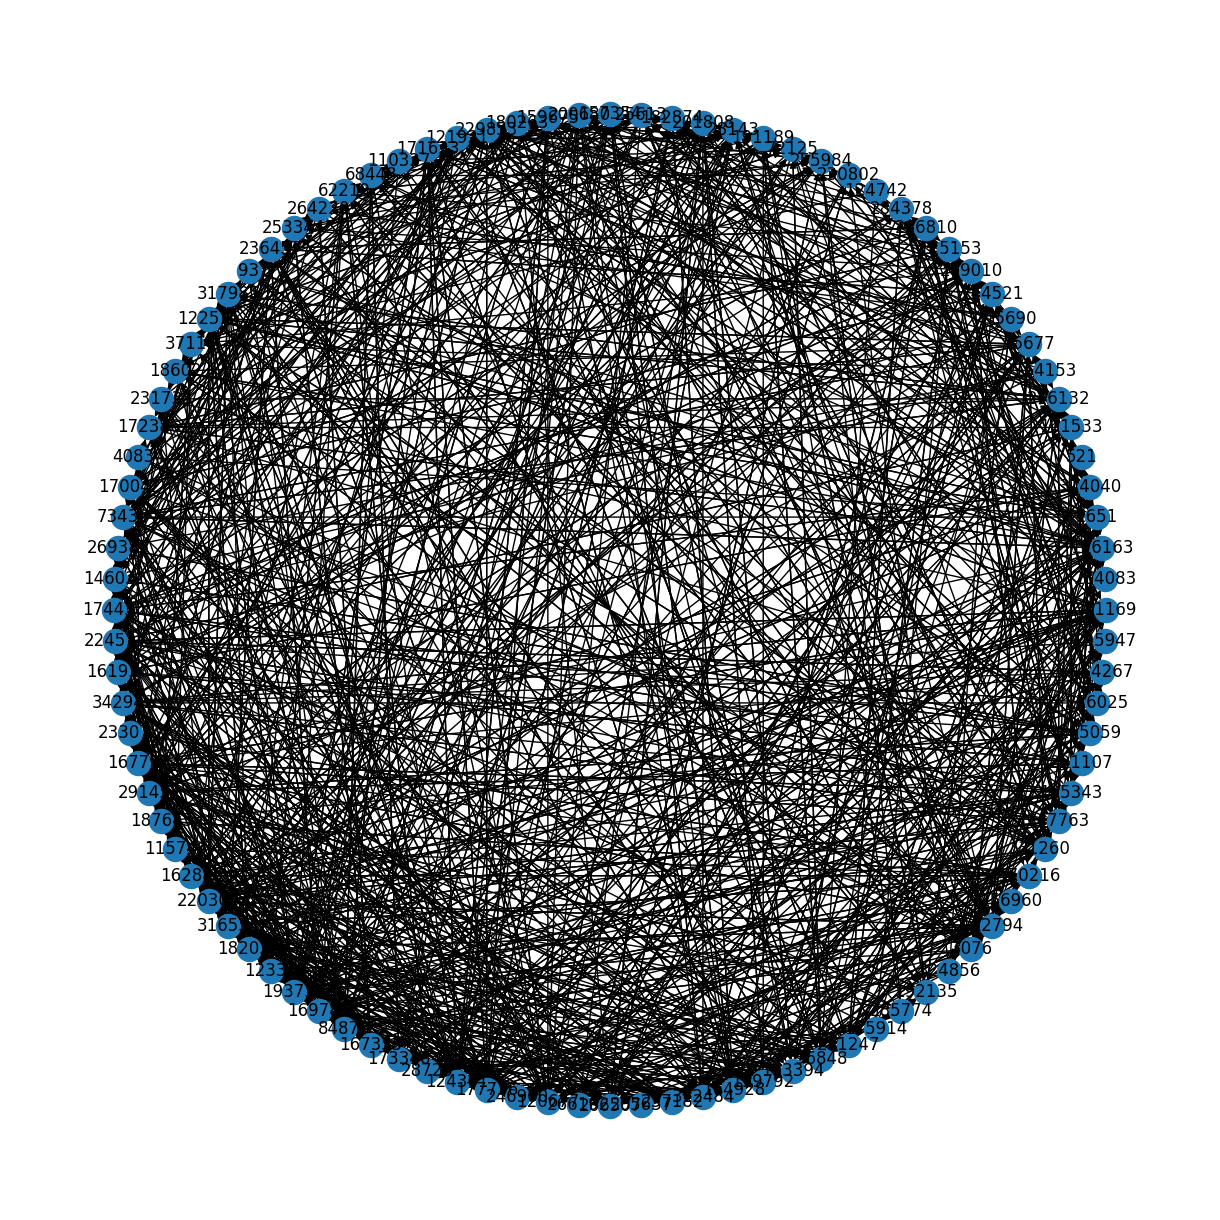

In [4]:
# Add nodes with attributes
for _, row in nodes_df.iterrows():
    G.add_node(row['id'],
               title=row['title'],
               year=row['year'],
               rank=row['rank'],
               rating=row['rating'],
               num_reviews=row['num_reviews'])

# Add edges
for _, row in edges_df.iterrows():
    G.add_edge(row['source'], row['target'])

# Print basic graph statistics
print("\nGraph Statistics:")
print(f"Number of nodes: {G.number_of_nodes()}")
print(f"Number of edges: {G.number_of_edges()}")
# Draw the graph
plt.figure(figsize=(12, 12))
pos = nx.shell_layout(G)
nx.draw(G, pos, with_labels=True)

In [5]:
# Analyze the network
print("\nNetwork Analysis:")
print(f"Is the graph connected? {nx.is_strongly_connected(G)}")

# Calculate in-degree and out-degree for each node
in_degrees = dict(G.in_degree())
out_degrees = dict(G.out_degree())

# Add in-degree and out-degree to nodes_df
nodes_df['in_degree'] = nodes_df['id'].map(in_degrees)
nodes_df['out_degree'] = nodes_df['id'].map(out_degrees)

print("\nGames with highest in-degree (most recommended):")
top_recommended = nodes_df.sort_values('in_degree', ascending=False).head(10)
for _, row in top_recommended.iterrows():
    print(f"{row['title']} (Rank: {row['rank']}): {row['in_degree']} recommendations")

print("\nGames with highest out-degree (most recommending):")
top_recommending = nodes_df.sort_values('out_degree', ascending=False).head(10)
for _, row in top_recommending.iterrows():
    print(f"{row['title']} (Rank: {row['rank']}): {row['out_degree']} recommendations")

# Calculate centrality measures
print("\nCalculating centrality measures...")
betweenness = nx.betweenness_centrality(G)
pagerank = nx.pagerank(G)

# Add centrality measures to the DataFrame
nodes_df['betweenness'] = nodes_df['id'].map(betweenness)
nodes_df['pagerank'] = nodes_df['id'].map(pagerank)

print("\nGames with highest PageRank (most influential):")
top_pagerank = nodes_df.sort_values('pagerank', ascending=False).head(10)
for _, row in top_pagerank.iterrows():
    print(f"{row['title']} (Rank: {row['rank']}): {row['pagerank']:.4f}")


Network Analysis:
Is the graph connected? False

Games with highest in-degree (most recommended):
Great Western Trail (Rank: 15): 39 recommendations
Terraforming Mars (Rank: 6): 34 recommendations
Scythe (Rank: 16): 33 recommendations
Caverna: The Cave Farmers (Rank: 40): 33 recommendations
Gaia Project (Rank: 11): 31 recommendations
Dune: Imperium (Rank: 12): 30 recommendations
Tzolk'in: The Mayan Calendar (Rank: 53): 30 recommendations
A Feast for Odin (Rank: 22): 30 recommendations
Concordia (Rank: 21): 30 recommendations
Terra Mystica (Rank: 24): 29 recommendations

Games with highest out-degree (most recommending):
Through the Ages: A New Story of Civilization (Rank: 13): 24 recommendations
Great Western Trail (Second Edition) (Rank: 51): 23 recommendations
Gaia Project (Rank: 11): 23 recommendations
Terraforming Mars (Rank: 6): 23 recommendations
A Feast for Odin (Rank: 22): 23 recommendations
Agricola (Revised Edition) (Rank: 77): 22 recommendations
Great Western Trail (Rank: 1

# Part 2: Use node2bec and visualize it

In [6]:
pip install networkx numpy pandas matplotlib scikit-learn node2vec

Defaulting to user installation because normal site-packages is not writeable
DEPRECATION: Loading egg at /Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/buildozer-1.5.1.dev0-py3.11.egg is deprecated. pip 24.3 will enforce this behaviour change. A possible replacement is to use pip for package installation.. Discussion can be found at https://github.com/pypa/pip/issues/12330

[notice] A new release of pip is available: 24.0 -> 25.0.1
[notice] To update, run: pip3.11 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [7]:
from sklearn.manifold import TSNE
from node2vec import Node2Vec
node2vec = Node2Vec(G, 
                    dimensions=64,  # Embedding dimension
                    walk_length=30,  # Length of each random walk
                    num_walks=200,   # Number of random walks per node
                    workers=4,       # Number of parallel workers
                    p=1,             # Return parameter
                    q=1)             # In-out parameter

# Train the model
model = node2vec.fit(window=10,     # Context window size
                     min_count=1,    # Minimum frequency of node occurrence
                     batch_words=4)  # Number of words per batch

# Get embeddings for all nodes
embeddings = {}
for node in G.nodes():
    embeddings[node] = model.wv[str(node)]

# Convert embeddings to numpy array for TSNE
embeddings_array = np.array(list(embeddings.values()))

# Apply TSNE for dimensionality reduction to 2D
tsne = TSNE(n_components=2, random_state=42)
embeddings_2d = tsne.fit_transform(embeddings_array)

# Create a DataFrame for easy plotting
node_ids = list(embeddings.keys())
embedding_df = pd.DataFrame({
    'node_id': node_ids,
    'x': embeddings_2d[:, 0],
    'y': embeddings_2d[:, 1]
})

Computing transition probabilities:   0%|          | 0/100 [00:00<?, ?it/s]

Generating walks (CPU: 4): 100%|██████████| 50/50 [00:00<00:00, 225.51it/s]


In [8]:
if 'year' in G.nodes[list(G.nodes())[0]]:  # Check if 'year' attribute exists
    years = [G.nodes[node]['year'] for node in node_ids]
    unique_years = sorted(set(years))
    color_map = {year: plt.cm.viridis(i/len(unique_years)) for i, year in enumerate(unique_years)}
    colors = [color_map[G.nodes[node]['year']] for node in node_ids]
else:
    # If year doesn't exist, use degree as color attribute
    degree = [G.degree(node) for node in node_ids]
    colors = plt.cm.viridis([d/max(degree) for d in degree])

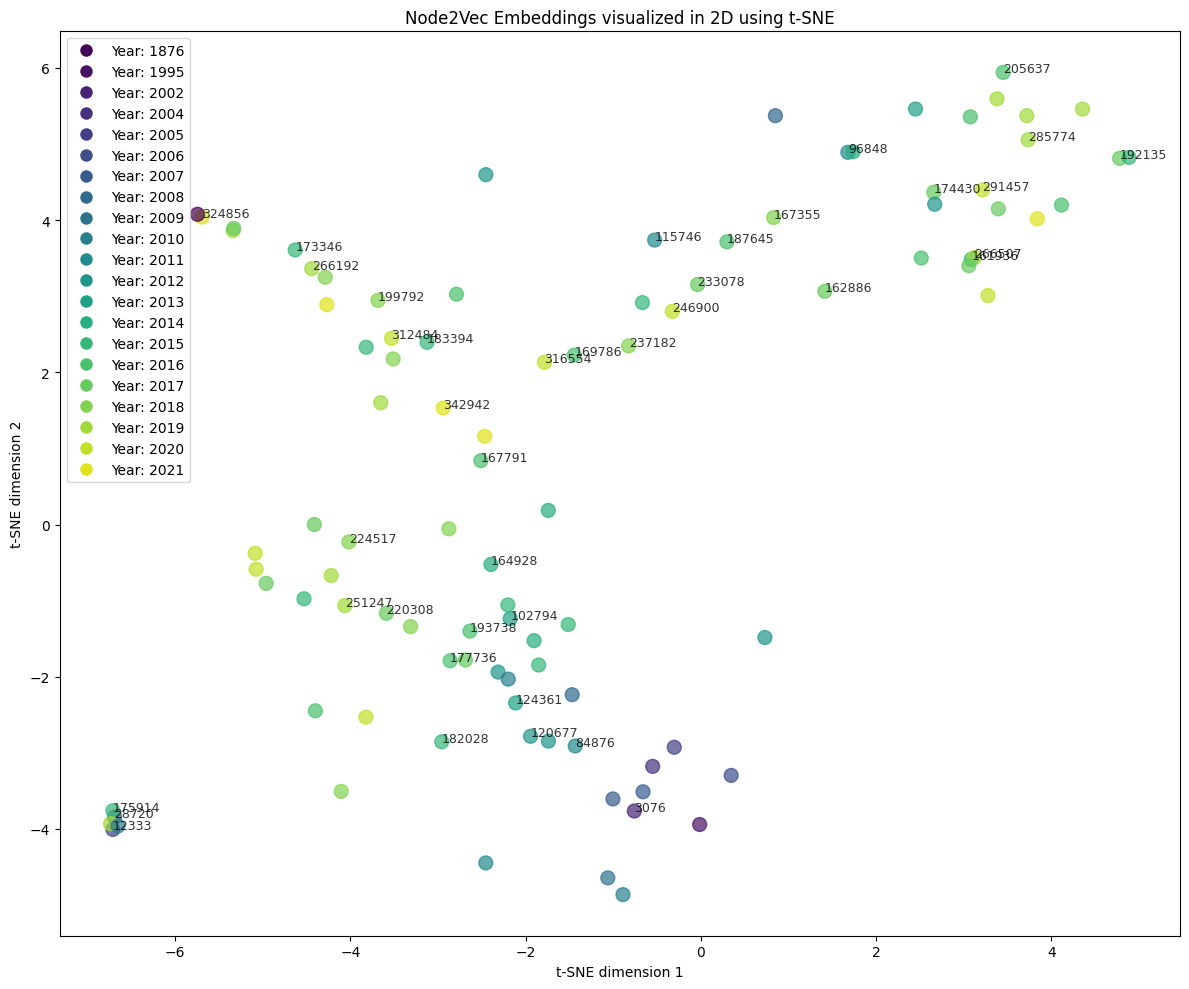

In [9]:
# Create the plot
plt.figure(figsize=(12, 10))
scatter = plt.scatter(embedding_df['x'], embedding_df['y'], 
                     c=colors, 
                     alpha=0.7,
                     s=100)

# Add node labels
for i, node in enumerate(node_ids):
    if i < 40:  # Only label the first 40 nodes to avoid clutter
        plt.annotate(str(node), 
                    (embedding_df.iloc[i]['x'], embedding_df.iloc[i]['y']),
                    fontsize=9,
                    alpha=0.8)

# Add a colorbar if using a continuous attribute like degree
if 'year' in G.nodes[list(G.nodes())[0]]:
    # Add a legend for discrete years
    from matplotlib.lines import Line2D
    legend_elements = [Line2D([0], [0], marker='o', color='w', 
                            markerfacecolor=color_map[year], markersize=10, 
                            label=f'Year: {year}') 
                    for year in sorted(unique_years)]
    plt.legend(handles=legend_elements, loc='best')
else:
    plt.colorbar(scatter, label='Node Degree')

plt.title('Node2Vec Embeddings visualized in 2D using t-SNE')
plt.xlabel('t-SNE dimension 1')
plt.ylabel('t-SNE dimension 2')
plt.tight_layout()
plt.show()

# Part 3: Create a Couple of bipartite graphs be using the other metadata
**In Order of Display: Category, Design, Creator**

In [10]:
# Function to visualize bipartite graph
def visualize_bipartite(G, title, pos=None):
    plt.figure(figsize=(14, 10))
    
    # Get node sets
    nodes = G.nodes(data=True)
    game_nodes = [n for n, d in nodes if d['bipartite'] == 0]
    attr_nodes = [n for n, d in nodes if d['bipartite'] == 1]
    
    # Generate positions if not provided
    if pos is None:
        pos = {}
        # Put game nodes on the left
        pos.update((node, (1, i)) for i, node in enumerate(game_nodes))
        # Put attribute nodes on the right
        pos.update((node, (2, i)) for i, node in enumerate(attr_nodes))
    
    # Get rating values for color mapping
    rating_values = [G.nodes[n]['rating'] for n in game_nodes]
    norm = Normalize(vmin=min(rating_values), vmax=max(rating_values))
    cmap = plt.cm.viridis
    
    # Draw nodes
    nx.draw_networkx_nodes(G, pos, nodelist=game_nodes, 
                           node_color=[G.nodes[n]['rating'] for n in game_nodes],
                           cmap=cmap, node_size=100, alpha=0.8)
    nx.draw_networkx_nodes(G, pos, nodelist=attr_nodes, node_color='lightblue', 
                           node_shape='s', node_size=150, alpha=0.8)
    
    # Draw edges
    nx.draw_networkx_edges(G, pos, width=0.5, alpha=0.3)
    
    # Add colorbar for ratings
    sm = ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=plt.gca(), label='Game Rating')
    
    # Add labels for attribute nodes only (to keep the viz cleaner)
    attr_labels = {node: G.nodes[node]['name'] for node in attr_nodes}
    nx.draw_networkx_labels(G, pos, labels=attr_labels, font_size=8)
    
    plt.title(title)
    plt.axis('off')
    plt.tight_layout()
    plt.savefig(f"{title.lower().replace(' ', '_')}.png", dpi=300, bbox_inches='tight')
    plt.show()

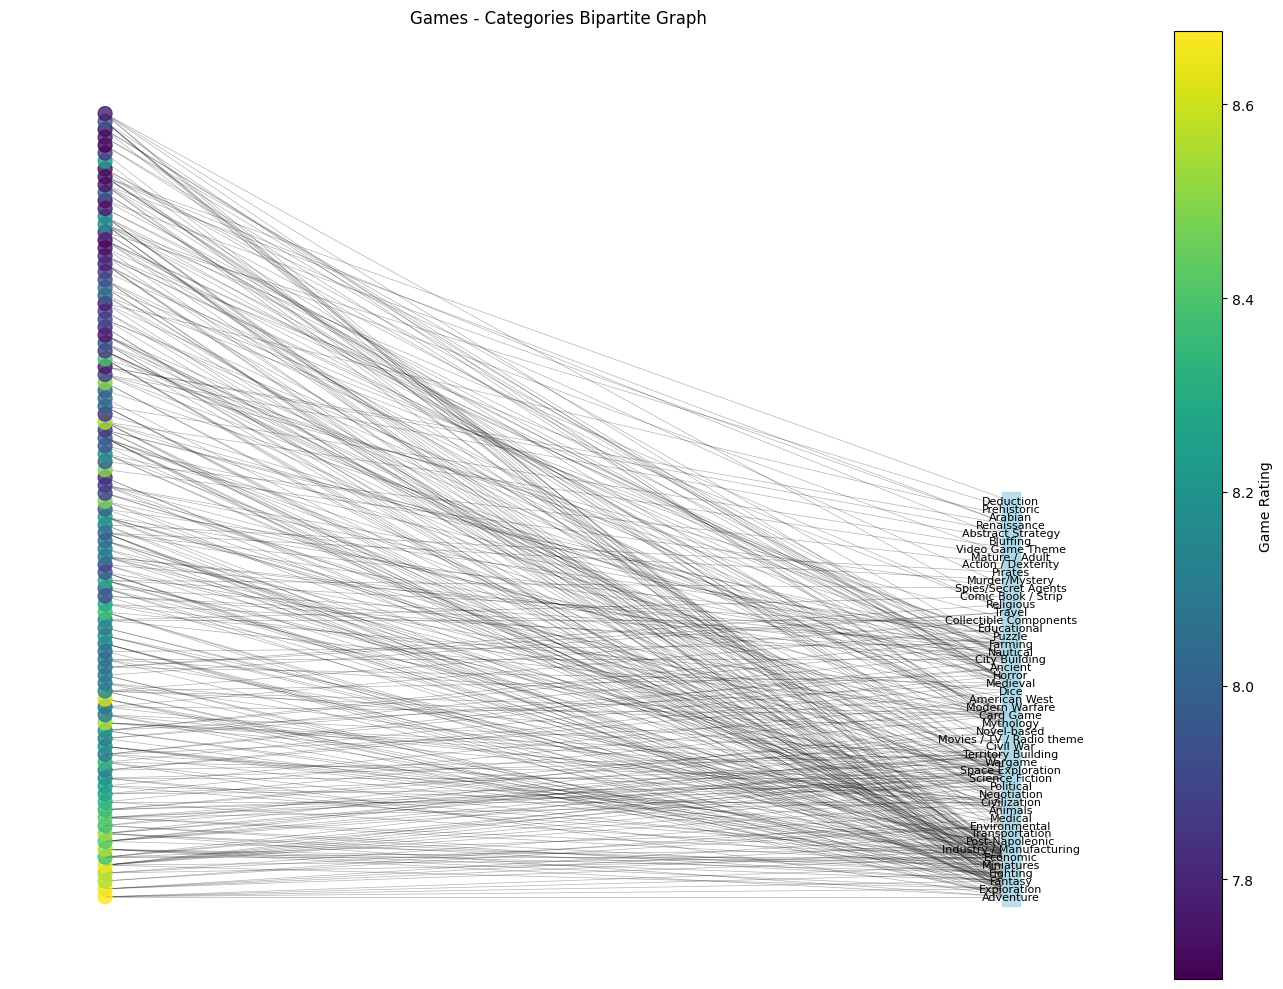

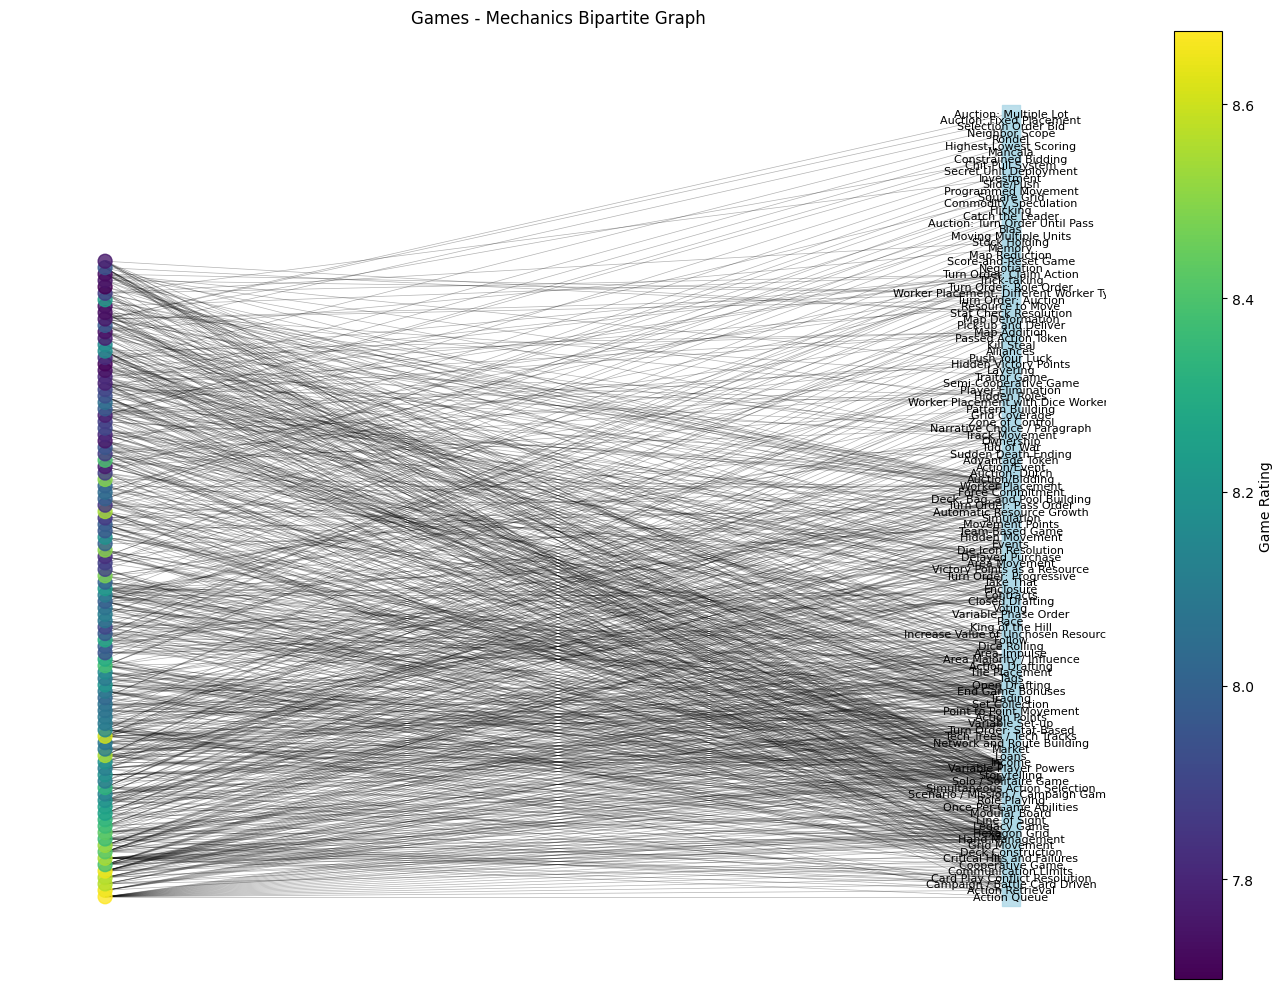

In [11]:
# Create bipartite graph for games and categories
G_categories = nx.Graph()

# Add game nodes
for game in boardgames:
    G_categories.add_node(game['id'], bipartite=0, title=game['title'], rating=game['rating']['rating'])
    
    # Add category nodes and edges
    if 'types' in game and 'categories' in game['types']:
        for category in game['types']['categories']:
            # Add category node if it doesn't exist
            if not G_categories.has_node(f"cat_{category['id']}"):
                G_categories.add_node(f"cat_{category['id']}", bipartite=1, name=category['name'])
            
            # Add edge between game and category
            G_categories.add_edge(game['id'], f"cat_{category['id']}")

# Create bipartite graph for games and mechanics
G_mechanics = nx.Graph()

# Add game nodes
for game in boardgames:
    G_mechanics.add_node(game['id'], bipartite=0, title=game['title'], rating=game['rating']['rating'])
    
    # Add mechanic nodes and edges
    if 'types' in game and 'mechanics' in game['types']:
        for mechanic in game['types']['mechanics']:
            # Add mechanic node if it doesn't exist
            if not G_mechanics.has_node(f"mech_{mechanic['id']}"):
                G_mechanics.add_node(f"mech_{mechanic['id']}", bipartite=1, name=mechanic['name'])
            
            # Add edge between game and mechanic
            G_mechanics.add_edge(game['id'], f"mech_{mechanic['id']}")

# Visualize the bipartite graphs
visualize_bipartite(G_categories, "Games - Categories Bipartite Graph")
visualize_bipartite(G_mechanics, "Games - Mechanics Bipartite Graph")

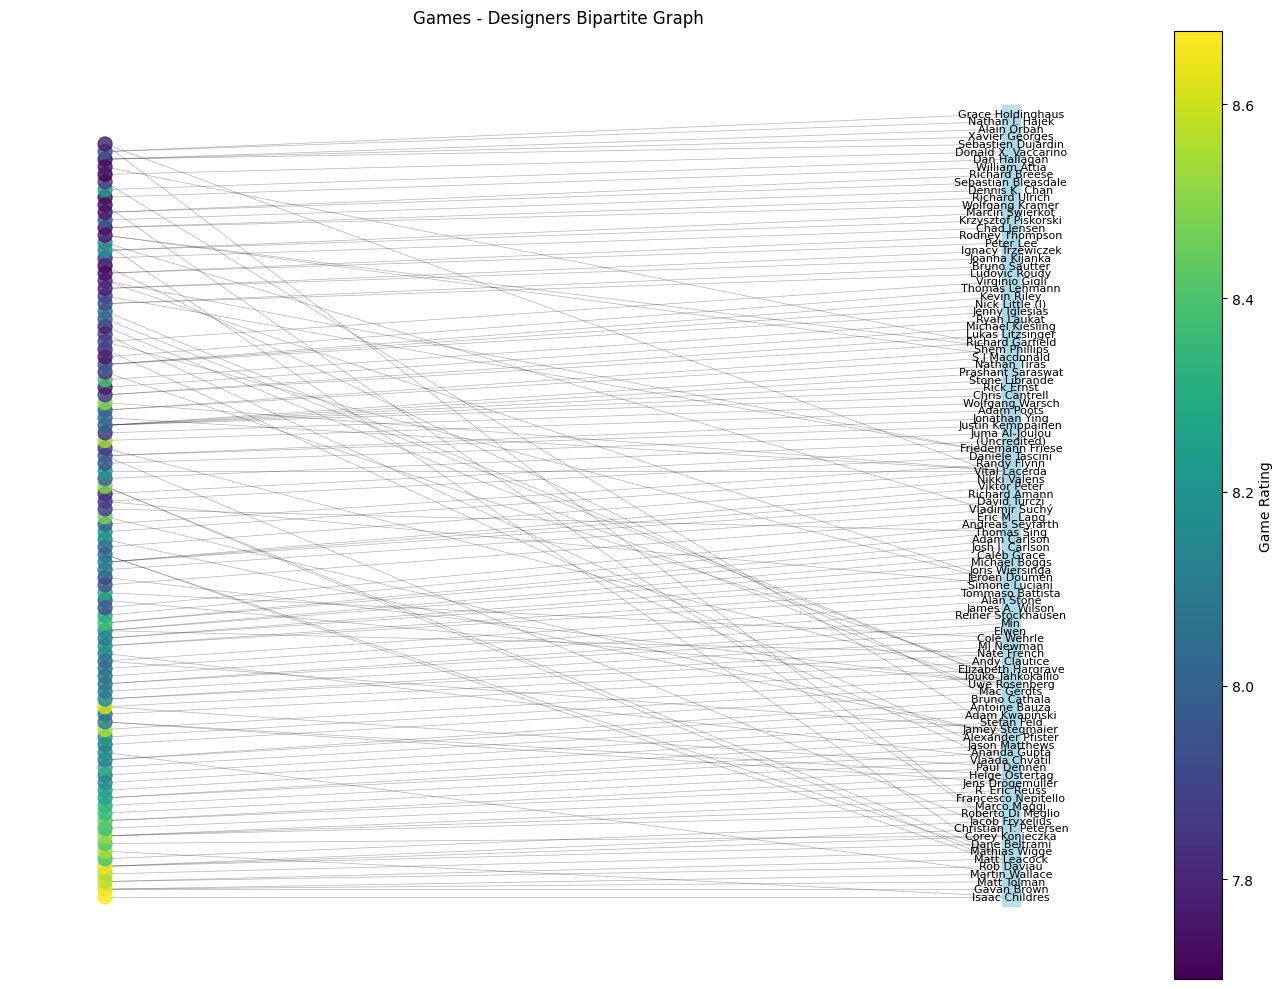

In [12]:
# Create a third bipartite graph for designers
G_designers = nx.Graph()

# Add game nodes and designer nodes
for game in boardgames:
    G_designers.add_node(game['id'], bipartite=0, title=game['title'], rating=game['rating']['rating'])
    
    # Add designer nodes and edges
    if 'credit' in game and 'designer' in game['credit']:
        for designer in game['credit']['designer']:
            # Add designer node if it doesn't exist
            if not G_designers.has_node(f"des_{designer['id']}"):
                G_designers.add_node(f"des_{designer['id']}", bipartite=1, name=designer['name'])
            
            # Add edge between game and designer
            G_designers.add_edge(game['id'], f"des_{designer['id']}")

# Visualize the designers bipartite graph
visualize_bipartite(G_designers, "Games - Designers Bipartite Graph")

# Part 4: Create the Projected Graphs

In [13]:
# Get game nodes and attribute nodes
game_nodes_categories = {n for n, d in G_categories.nodes(data=True) if d['bipartite'] == 0}
category_nodes = {n for n, d in G_categories.nodes(data=True) if d['bipartite'] == 1}

game_nodes_designers = {n for n, d in G_designers.nodes(data=True) if d['bipartite'] == 0}
designer_nodes = {n for n, d in G_designers.nodes(data=True) if d['bipartite'] == 1}

# Create projected graphs
# Two games are connected if they share at least one category
G_proj_categories = nx.bipartite.projected_graph(G_categories, game_nodes_categories)

# Two games are connected if they share at least one designer
G_proj_designers = nx.bipartite.projected_graph(G_designers, game_nodes_designers)

In [14]:
def visualize_projected_graph(G, title, weight_attr=None):
    plt.figure(figsize=(14, 12))
    
    # Get node attributes from original graph
    node_ratings = {}
    node_titles = {}
    for node in G.nodes():
        if 'rating' in G_categories.nodes[node]:
            node_ratings[node] = G_categories.nodes[node]['rating']
        if 'title' in G_categories.nodes[node]:
            node_titles[node] = G_categories.nodes[node]['title']
    
    # Calculate node sizes based on degree
    degrees = dict(G.degree())
    node_sizes = [50 + 10 * degrees[n] for n in G.nodes()]
    
    # Use spring layout for better visualization
    pos = nx.spring_layout(G, seed=42, k=0.3)
    
    # Draw nodes with color based on rating
    norm = Normalize(vmin=min(node_ratings.values()), vmax=max(node_ratings.values()))
    cmap = plt.cm.viridis
    
    # Draw edges (with width based on weight if available)
    if weight_attr:
        edge_weights = [G[u][v][weight_attr] for u, v in G.edges()]
        max_weight = max(edge_weights) if edge_weights else 1
        edge_widths = [0.5 + 3 * (w / max_weight) for w in edge_weights]
        nx.draw_networkx_edges(G, pos, width=edge_widths, alpha=0.3, edge_color='gray')
    else:
        nx.draw_networkx_edges(G, pos, width=0.7, alpha=0.3, edge_color='gray')
    
    # Draw nodes
    nodes = nx.draw_networkx_nodes(G, pos, 
                                  node_color=[node_ratings[n] for n in G.nodes()],
                                  cmap=cmap, 
                                  node_size=node_sizes,
                                  alpha=0.8)
    
    # Add colorbar
    sm = ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=plt.gca(), label='Game Rating')
    
    # Add labels only for high-degree nodes to avoid clutter
    threshold = max(degrees.values()) * 0.7
    labels = {n: node_titles[n] for n in G.nodes() if degrees[n] >= threshold}
    nx.draw_networkx_labels(G, pos, labels=labels, font_size=8, font_weight='bold')
    
    plt.title(title)
    plt.axis('off')
    plt.tight_layout()
    plt.savefig(f"{title.lower().replace(' ', '_')}.png", dpi=300, bbox_inches='tight')
    plt.show()

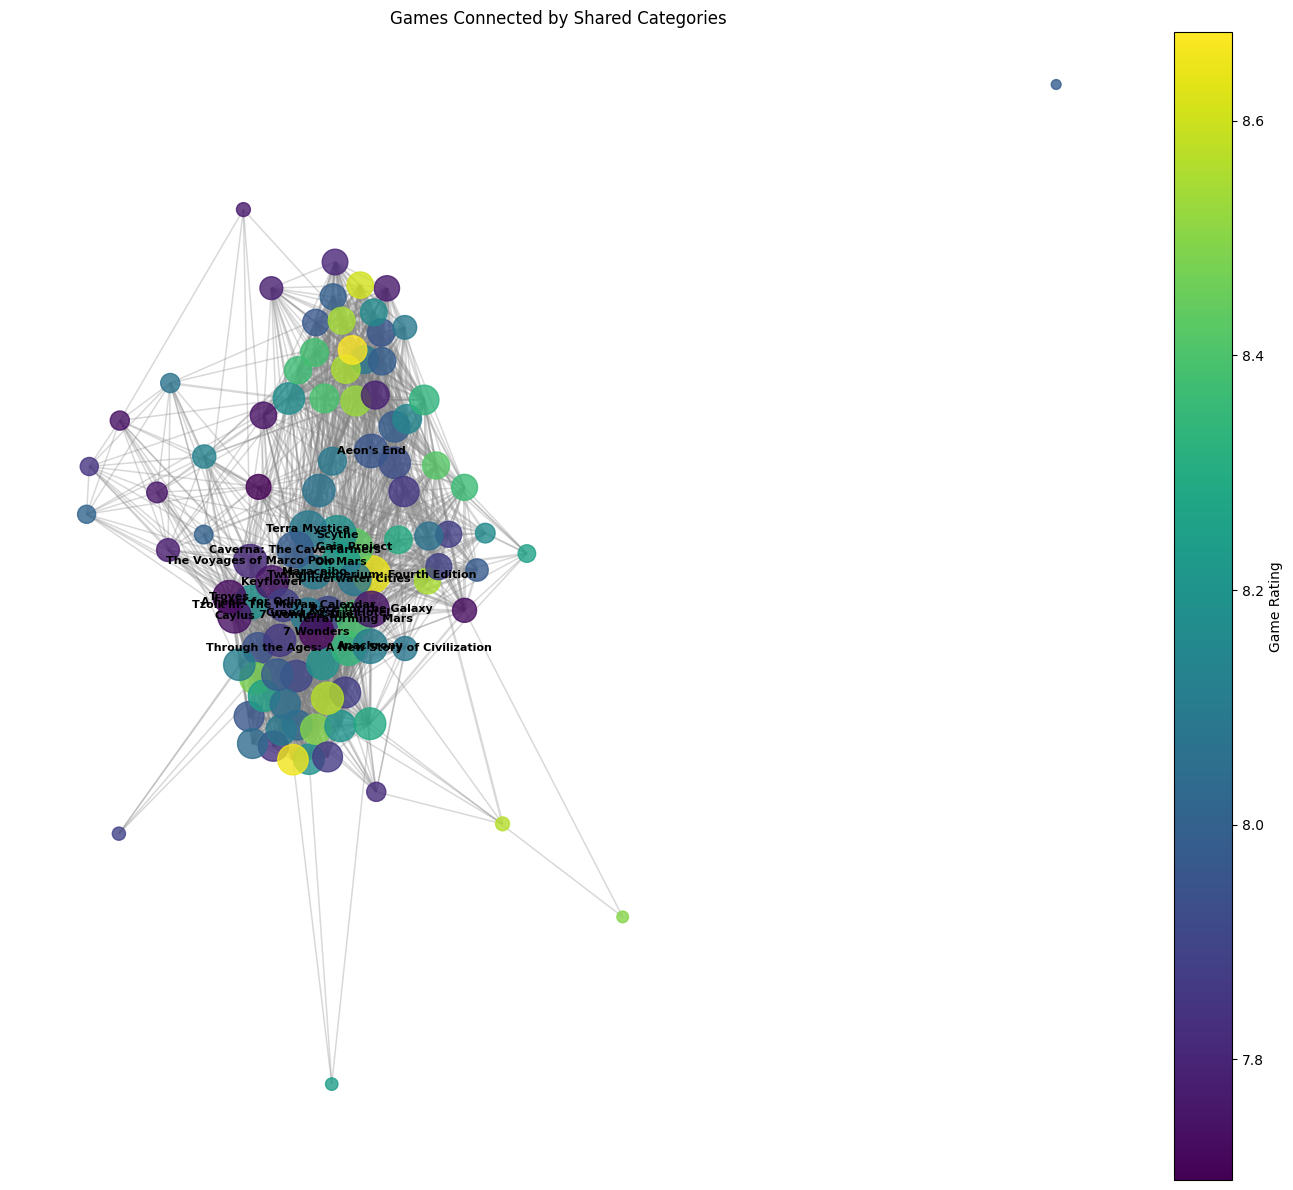

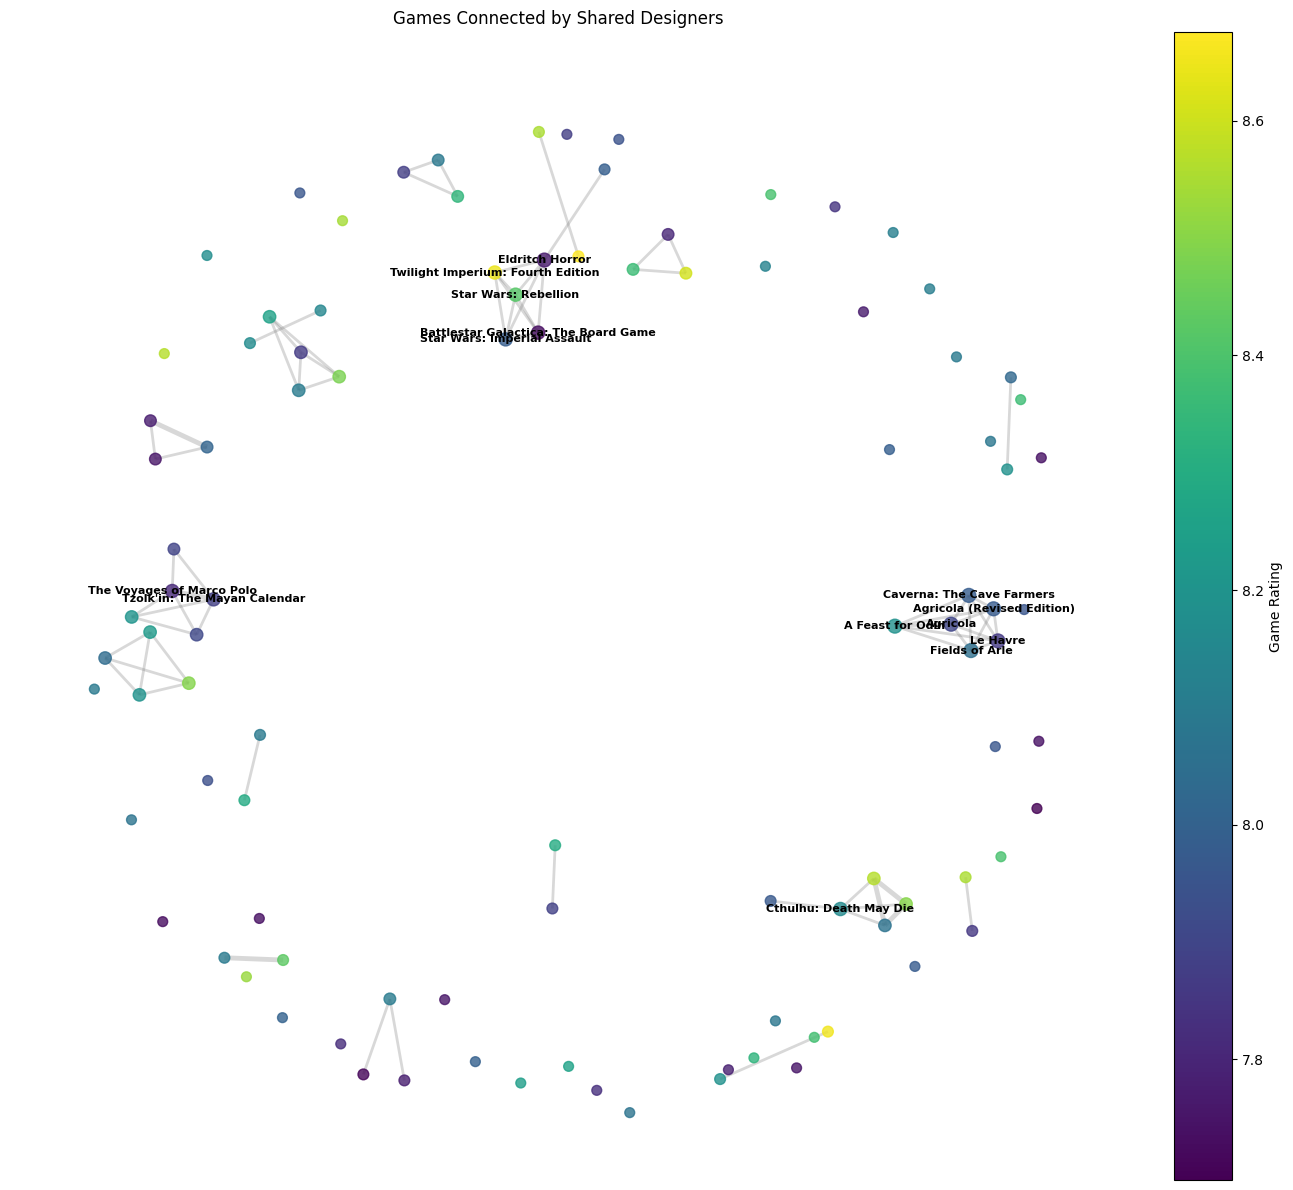

In [15]:
# Add edge weights to the category projection (number of shared categories)
for u, v in G_proj_categories.edges():
    # Find common categories between games u and v
    u_neighbors = set(G_categories.neighbors(u))
    v_neighbors = set(G_categories.neighbors(v))
    common_categories = u_neighbors.intersection(v_neighbors)
    
    # Set edge weight as the number of shared categories
    G_proj_categories[u][v]['weight'] = len(common_categories)

# Add edge weights to the designer projection (number of shared designers)
for u, v in G_proj_designers.edges():
    # Find common designers between games u and v
    u_neighbors = set(G_designers.neighbors(u))
    v_neighbors = set(G_designers.neighbors(v))
    common_designers = u_neighbors.intersection(v_neighbors)
    
    # Set edge weight as the number of shared designers
    G_proj_designers[u][v]['weight'] = len(common_designers)

# Visualize the projected graphs
visualize_projected_graph(G_proj_categories, "Games Connected by Shared Categories", weight_attr='weight')
visualize_projected_graph(G_proj_designers, "Games Connected by Shared Designers", weight_attr='weight')

# Part 5: Design an interesting problem for the dataset and implement the solution
**Finding Key Influencer Games in the Board Game Network**

Problem: Identify which games serve as "bridge games" that connect different categories/mechanics and potentially introduce players to new game types.
This can be solved using:

- Calculate betweenness centrality in the projected graphs to find games that sit between different clusters
- Identify games that combine typically unrelated categories or mechanics (cross-genre games)
- Analyze which games are most often co-liked with games from different categories (based on the recommendations/fans_liked data)
- Find "gateway games" that have high ratings but use mechanics that appear in many different types of games

This analysis would help:

- Game stores recommend diversification paths for customers
- Publishers identify potential market gaps
- Understand which game design combinations most effectively bridge different gaming communities

In [16]:
# Create an empty graph
G = nx.Graph()

# Add nodes for each game
for game in boardgames:
    game_id = game['id']
    title = game['title']
    rating = game['rating']['rating']
    G.add_node(game_id, title=title, rating=rating)

    # Add edges for recommendations (fans_liked)
    for recommended_game_id in game['recommendations']['fans_liked']:
        G.add_edge(game_id, recommended_game_id, relationship='recommended')

    # Add edges for shared categories
    categories = [category['name'] for category in game['types']['categories']]
    for other_game in boardgames:  # Use other_game directly here
        if other_game['id'] != game_id:  # Compare ids
            other_categories = [cat['name'] for cat in other_game['types']['categories']]
            if any(cat in categories for cat in other_categories):  # Check for common categories
                G.add_edge(game_id, other_game['id'], relationship='shared_category')

    # Add edges for shared mechanics
    mechanics = [mechanic['name'] for mechanic in game['types']['mechanics']]
    for other_game in boardgames:  # Use other_game directly here
        if other_game['id'] != game_id:  # Compare ids
            other_mechanics = [m['name'] for m in other_game['types']['mechanics']]
            if any(m in mechanics for m in other_mechanics):  # Check for common mechanics
                G.add_edge(game_id, other_game['id'], relationship='shared_mechanic')

In [17]:
# Calculate betweenness centrality
betweenness = nx.betweenness_centrality(G)

# Sort the games by betweenness centrality (highest to lowest)
sorted_betweenness = sorted(betweenness.items(), key=lambda x: x[1], reverse=True)

# Display top 10 bridge games (highest betweenness centrality)
top_10_bridge_games = sorted_betweenness[:10]
for game_id, centrality in top_10_bridge_games:
    game = G.nodes[game_id]
    print(f"Game: {game['title']}, Betweenness Centrality: {centrality}")


Game: Pax Pamir: Second Edition, Betweenness Centrality: 0.05648564277439166
Game: Twilight Struggle, Betweenness Centrality: 0.05332664071018992
Game: Android: Netrunner, Betweenness Centrality: 0.05210253307361777
Game: Star Wars: Imperial Assault, Betweenness Centrality: 0.044527399662406764
Game: Crokinole, Betweenness Centrality: 0.04416539662033534
Game: Dominion: Intrigue, Betweenness Centrality: 0.03712953690116356
Game: Azul, Betweenness Centrality: 0.03674019454627699
Game: Marvel Champions: The Card Game, Betweenness Centrality: 0.0362913323392038
Game: Food Chain Magnate, Betweenness Centrality: 0.03622911261371553
Game: Cascadia, Betweenness Centrality: 0.03524457310736238


In [29]:
# Now let's find the gateway games (games with high ratings and that bridge different genres)
gateway_games = []
for game in boardgames:
    rating = game['rating']['rating']
    game_id = game['id']
    
    if rating >= 8.0:  # High rating filter
        # Find games that connect multiple genres (e.g., cross-genre games)
        connected_categories = set()
        for neighbor in G.neighbors(game_id):
            # Safely get the neighbor game from boardgames (handle missing games gracefully)
            neighbor_game = next((g for g in boardgames if g['id'] == neighbor), None)
            
            if neighbor_game:  # Only proceed if the neighbor game is found
                connected_categories.update([category['name'] for category in neighbor_game['types']['categories']])
            #else:
                # Print missing neighbor game IDs for debugging
                #print(f"Warning: Game ID {neighbor} not found in boardgames list.")

        # If the game connects multiple genres, consider it a gateway game
        if len(connected_categories) > 1:
            gateway_games.append(game)

# Display the gateway games
print("\nGateway Games (High Rating and Cross-Genre):")
for game in gateway_games:
    print(f"Game: {game['title']}, Rating: {game['rating']['rating']}")



Gateway Games (High Rating and Cross-Genre):
Game: Gloomhaven, Rating: 8.67527
Game: Brass: Birmingham, Rating: 8.65313
Game: Pandemic Legacy: Season 1, Rating: 8.56688
Game: Ark Nova, Rating: 8.56684
Game: Twilight Imperium: Fourth Edition, Rating: 8.6449
Game: Terraforming Mars, Rating: 8.39103
Game: Gloomhaven: Jaws of the Lion, Rating: 8.55175
Game: Star Wars: Rebellion, Rating: 8.41817
Game: War of the Ring: Second Edition, Rating: 8.52576
Game: Spirit Island, Rating: 8.36924
Game: Gaia Project, Rating: 8.42974
Game: Dune: Imperium, Rating: 8.36497
Game: Through the Ages: A New Story of Civilization, Rating: 8.3355
Game: Twilight Struggle, Rating: 8.26264
Game: Great Western Trail, Rating: 8.25687
Game: Scythe, Rating: 8.1865
Game: The Castles of Burgundy, Rating: 8.12806
Game: Nemesis, Rating: 8.33096
Game: 7 Wonders Duel, Rating: 8.0984
Game: Brass: Lancashire, Rating: 8.18934
Game: Concordia, Rating: 8.11031
Game: A Feast for Odin, Rating: 8.18794
Game: Eclipse: Second Dawn fo

In [24]:
# Identify cross-genre games based on categories and mechanics diversity
cross_genre_games = []

for game in boardgames:
    categories = [category['name'] for category in game['types']['categories']]
    mechanics = [mechanic['name'] for mechanic in game['types']['mechanics']]
    
    if len(set(categories)) > 2 and len(set(mechanics)) > 2:  # threshold for diversity
        cross_genre_games.append(game)

for game in cross_genre_games:
    print(f"Cross-Genre Game: {game['title']}")

Cross-Genre Game: Gloomhaven
Cross-Genre Game: Brass: Birmingham
Cross-Genre Game: Ark Nova
Cross-Genre Game: Twilight Imperium: Fourth Edition
Cross-Genre Game: Terraforming Mars
Cross-Genre Game: Gloomhaven: Jaws of the Lion
Cross-Genre Game: Star Wars: Rebellion
Cross-Genre Game: War of the Ring: Second Edition
Cross-Genre Game: Spirit Island
Cross-Genre Game: Gaia Project
Cross-Genre Game: Dune: Imperium
Cross-Genre Game: Through the Ages: A New Story of Civilization
Cross-Genre Game: Twilight Struggle
Cross-Genre Game: Great Western Trail
Cross-Genre Game: Scythe
Cross-Genre Game: The Castles of Burgundy
Cross-Genre Game: Nemesis
Cross-Genre Game: 7 Wonders Duel
Cross-Genre Game: Brass: Lancashire
Cross-Genre Game: Concordia
Cross-Genre Game: A Feast for Odin
Cross-Genre Game: Eclipse: Second Dawn for the Galaxy
Cross-Genre Game: Terra Mystica
Cross-Genre Game: Wingspan
Cross-Genre Game: Clank!: Legacy – Acquisitions Incorporated
Cross-Genre Game: Arkham Horror: The Card Game
Cros

In [27]:
# List of cross-genre games from earlier step
cross_genre_games_set = set([game['id'] for game in cross_genre_games])

# Find gateway games with high ratings, diverse recommendations, and cross-genre appeal
gateway_games_json = []

for game in boardgames:
    rating = game['rating']['rating']
    recommendations = game['recommendations']['fans_liked']
    
    # Check if the game has a high rating and diverse recommendations
    if rating >= 8.0 and len(recommendations) > 10:
        # Check if the game is also a cross-genre game (i.e., appears in the cross-genre set)
        if game['id'] in cross_genre_games_set:
            gateway_games_json.append(game)

# Display gateway games
print("Gateway Games (Highly Rated and Cross-Genre):")
for game in gateway_games_json:
    print(f"Game: {game['title']}, Rating: {game['rating']['rating']}")

Gateway Games (Highly Rated and Cross-Genre):
Game: Gloomhaven, Rating: 8.67527
Game: Brass: Birmingham, Rating: 8.65313
Game: Ark Nova, Rating: 8.56684
Game: Twilight Imperium: Fourth Edition, Rating: 8.6449
Game: Terraforming Mars, Rating: 8.39103
Game: Gloomhaven: Jaws of the Lion, Rating: 8.55175
Game: Star Wars: Rebellion, Rating: 8.41817
Game: War of the Ring: Second Edition, Rating: 8.52576
Game: Spirit Island, Rating: 8.36924
Game: Gaia Project, Rating: 8.42974
Game: Dune: Imperium, Rating: 8.36497
Game: Through the Ages: A New Story of Civilization, Rating: 8.3355
Game: Twilight Struggle, Rating: 8.26264
Game: Great Western Trail, Rating: 8.25687
Game: Scythe, Rating: 8.1865
Game: The Castles of Burgundy, Rating: 8.12806
Game: Nemesis, Rating: 8.33096
Game: 7 Wonders Duel, Rating: 8.0984
Game: Brass: Lancashire, Rating: 8.18934
Game: Concordia, Rating: 8.11031
Game: A Feast for Odin, Rating: 8.18794
Game: Eclipse: Second Dawn for the Galaxy, Rating: 8.55169
Game: Terra Mystica

In [28]:
# Find which games are in all three list

# Create sets of game IDs or titles for each category
bridge_games_set = set([game_id for game_id, _ in top_10_bridge_games])  # Extracting game IDs from tuple
cross_genre_games_set = set([game['id'] for game in cross_genre_games])
gateway_games_set = set([game['id'] for game in gateway_games])

# Find the intersection (games that appear in all three lists)
common_games = bridge_games_set & cross_genre_games_set & gateway_games_set

# Display common games
print("Games in all three lists (Bridge, Cross-Genre, and Gateway):")
for game_id in common_games:
    # Find the game details using the game ID
    game = next(game for game in boardgames if game['id'] == game_id)
    print(f"Game: {game['title']}, ID: {game['id']}, Rating: {game['rating']['rating']}")


Games in all three lists (Bridge, Cross-Genre, and Gateway):
Game: Pax Pamir: Second Edition, ID: 256960, Rating: 8.28948
Game: Twilight Struggle, ID: 12333, Rating: 8.26264
Game: Marvel Champions: The Card Game, ID: 285774, Rating: 8.16512
